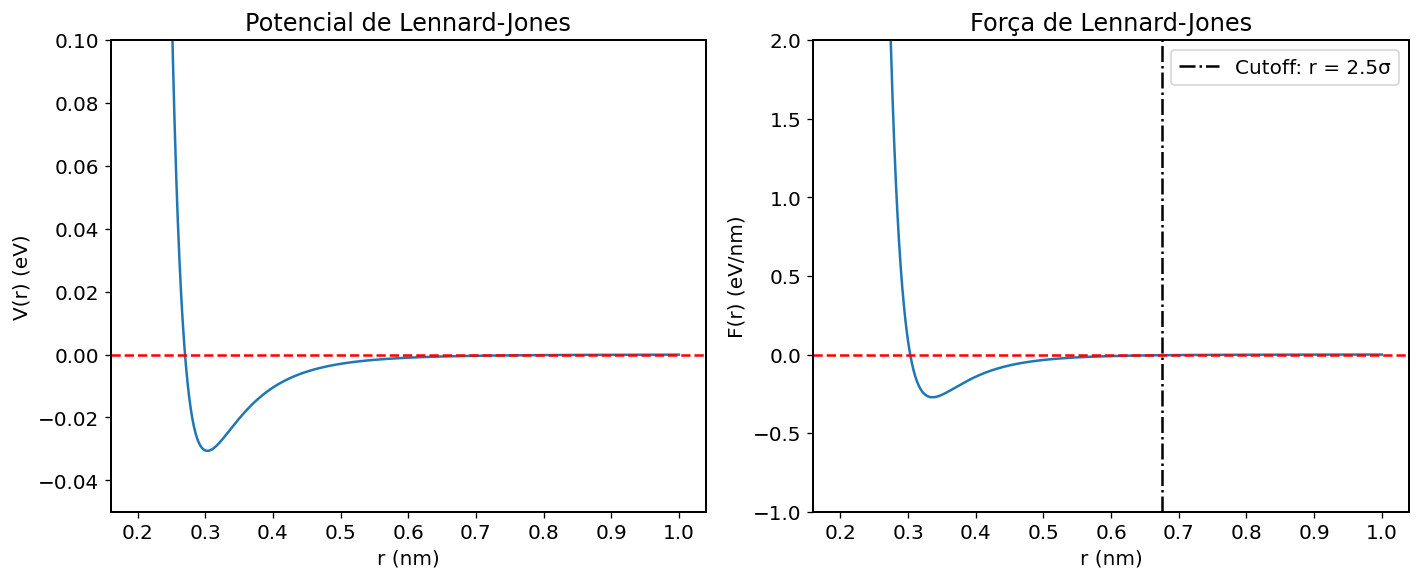

Epsilon em eV: 0.03064580955560235 eV
Força à 1.3σ (mínimo do potencial): F(1.3σ) = -0.2542444382842626 eV/nm
Força à 2.5σ (cutoff): F(2.5σ) = -0.004426557625135248 eV/nm


In [17]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.linewidth"] = 1.2

# -----------------------
# Parâmetros físicos
# -----------------------
sigma = 0.27  # nm
epsilon_J = 4.91e-21  # J

# Conversão para eV
J_to_eV = 1.602176634e-19
epsilon = epsilon_J / J_to_eV  # eV

# -----------------------
# Definição do raio
# -----------------------
r = np.linspace(0.2, 1.0, 1000)  # nm

# -----------------------
# Potencial Lennard-Jones
# V(r) = 4ε[(σ/r)^12 - (σ/r)^6]
# -----------------------
V = 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

# -----------------------
# Força F(r) = -dV/dr
# Derivada analítica:
# F(r) = 24ε/r [2(σ/r)^12 - (σ/r)^6]
# -----------------------
F = (24 * epsilon / r) * (2*(sigma/r)**12 - (sigma/r)**6)

# -----------------------
# Plot lado a lado
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Potencial
ax[0].plot(r, V)
ax[0].axhline(0, linestyle='--', color='red')
ax[0].set_xlabel("r (nm)")
ax[0].set_ylabel("V(r) (eV)")
ax[0].set_title("Potencial de Lennard-Jones")
ax[0].set_ylim(-0.05, 0.1)

# Força
ax[1].plot(r, F)
ax[1].axhline(0, linestyle='--', color='red')
ax[1].axvline(2.5*sigma, linestyle='-.', color='black', label='Cutoff: r = 2.5σ')
ax[1].set_xlabel("r (nm)")
ax[1].set_ylabel("F(r) (eV/nm)")
ax[1].set_title("Força de Lennard-Jones")
ax[1].set_ylim(-1, 2)

plt.tight_layout()
plt.legend()
plt.show()

print("Epsilon em eV:", epsilon, "eV")
print("Força à 1.3σ (mínimo do potencial): F(1.3σ) =", (24 * epsilon / (1.3*sigma)) * (2*(sigma/(1.3*sigma))**12 - (sigma/(1.3*sigma))**6), "eV/nm")
print("Força à 2.5σ (cutoff): F(2.5σ) =", (24 * epsilon / (2.5*sigma)) * (2*(sigma/(2.5*sigma))**12 - (sigma/(2.5*sigma))**6), "eV/nm")

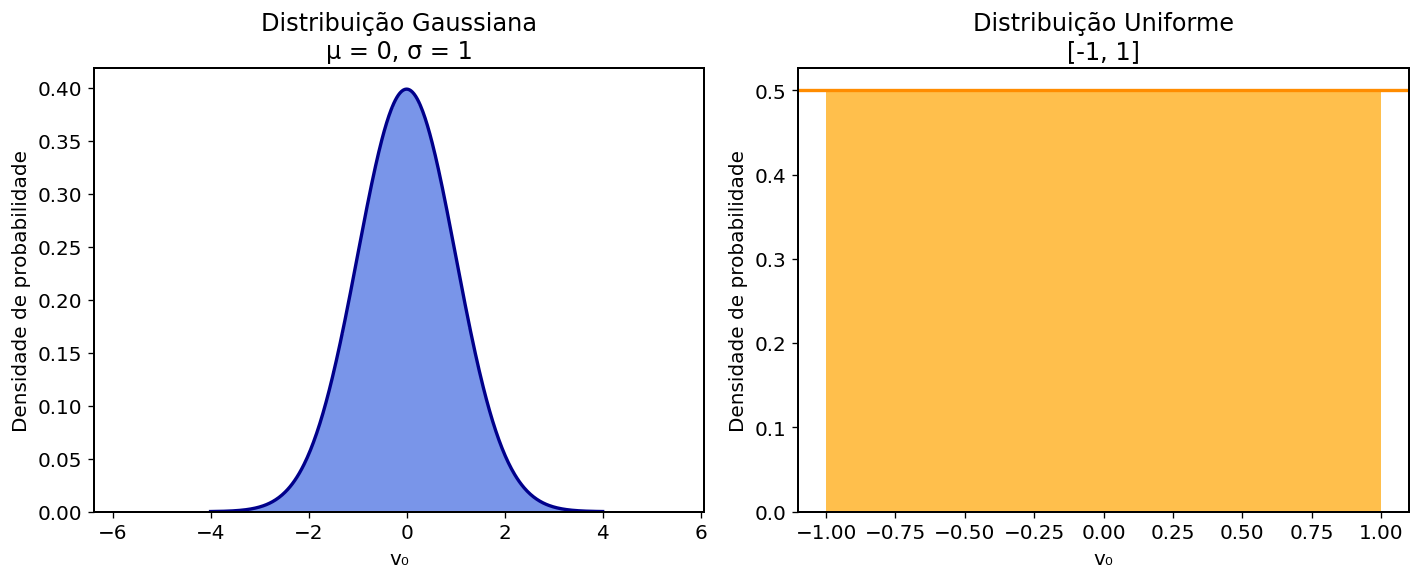

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.linewidth"] = 1.2

# -----------------------
# Número de amostras
# -----------------------
N = 80000000

# -----------------------
# Gerando distribuições
# -----------------------
gaussian = np.random.normal(loc=0, scale=1, size=N)
uniform = np.random.uniform(low=-1, high=1, size=N)

# -----------------------
# Plot lado a lado
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# --- Gaussiana ---
ax[0].hist(gaussian, bins=200, density=True, alpha=0.7, color='royalblue')
x = np.linspace(-4, 4, 500)
ax[0].plot(x, norm.pdf(x, 0, 1), color='darkblue', linewidth=2)
ax[0].set_title("Distribuição Gaussiana\nμ = 0, σ = 1")
ax[0].set_xlabel("v₀")
ax[0].set_ylabel("Densidade de probabilidade")

# --- Uniforme ---
ax[1].hist(uniform, bins=100, density=True, alpha=0.7, color='orange')
ax[1].axhline(0.5, color='darkorange', linewidth=2)  # densidade teórica = 1/(b-a) = 1/2
ax[1].set_title("Distribuição Uniforme\n[-1, 1]")
ax[1].set_xlabel("v₀")
ax[1].set_ylabel("Densidade de probabilidade")

plt.tight_layout()
plt.show()